In [5]:
import pandas as pd
data=pd.read_csv("/content/customer_churn_dataset-training-master.csv")
df=pd.DataFrame(data)
df.head()
df.shape
df.dtypes
df.select_dtypes(include="number").columns.tolist()
df.select_dtypes(include=["object","category"]).columns.tolist()
df.isnull()
df.isnull().sum()
target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]

df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41315 entries, 0 to 41314
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         41315 non-null  int64  
 1   Age                41315 non-null  int64  
 2   Gender             41315 non-null  object 
 3   Tenure             41315 non-null  int64  
 4   Usage Frequency    41315 non-null  int64  
 5   Support Calls      41315 non-null  int64  
 6   Payment Delay      41315 non-null  int64  
 7   Subscription Type  41314 non-null  object 
 8   Contract Length    41314 non-null  object 
 9   Total Spend        41315 non-null  float64
 10  Last Interaction   41315 non-null  float64
 11  Churn              41315 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 3.8+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,41315.000000,41315.000000,41315.000000,41315.000000,41315.000000,41315.000000,41315.000000,41315.000000,41315.000000
mean,20712.473678,41.518770,30.503110,15.469466,5.032022,15.032046,549.455148,15.498185,0.967856
std,11995.495870,13.863462,17.419545,8.690747,3.156166,8.963084,259.153609,8.662812,0.176383
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,10337.500000,29.000000,15.000000,8.000000,2.000000,7.000000,325.000000,8.000000,1.000000
50%,20666.000000,42.000000,31.000000,15.000000,5.000000,15.000000,550.000000,16.000000,1.000000
75%,30994.500000,54.000000,46.000000,23.000000,8.000000,23.000000,772.000000,23.000000,1.000000
max,41725.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df.isnull()
df.isnull().sum()

df["Contract Length"].unique()
df["Subscription Type"].unique()
df["Gender"].unique()

categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode())


df.duplicated()
df.duplicated().sum()
df.drop_duplicates().shape[0]

for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip() # Strip spaces
print(df.info())

df["CustomerID"]=df["CustomerID"].astype(int)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41315 entries, 0 to 41314
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         41315 non-null  int64  
 1   Age                41315 non-null  int64  
 2   Gender             41315 non-null  object 
 3   Tenure             41315 non-null  int64  
 4   Usage Frequency    41315 non-null  int64  
 5   Support Calls      41315 non-null  int64  
 6   Payment Delay      41315 non-null  int64  
 7   Subscription Type  41315 non-null  object 
 8   Contract Length    41315 non-null  object 
 9   Total Spend        41315 non-null  float64
 10  Last Interaction   41315 non-null  float64
 11  Churn              41315 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 3.8+ MB
None


Churn
1    39987
0     1328
Name: count, dtype: int64
Churn
1    96.785671
0     3.214329
Name: proportion, dtype: float64


,count
Churn,
1,39987
0,1328


,proportion
Churn,
1,96.785671
0,3.214329


/tmp/ipykernel_946/2235874397.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


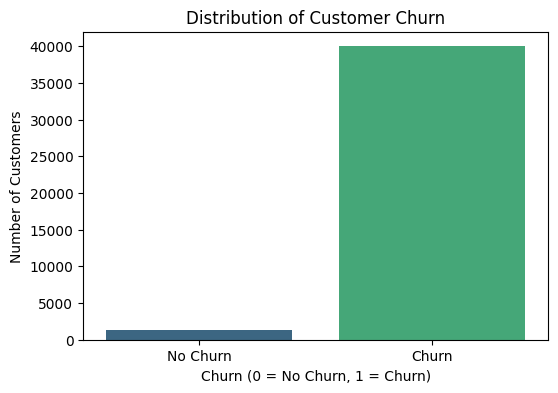

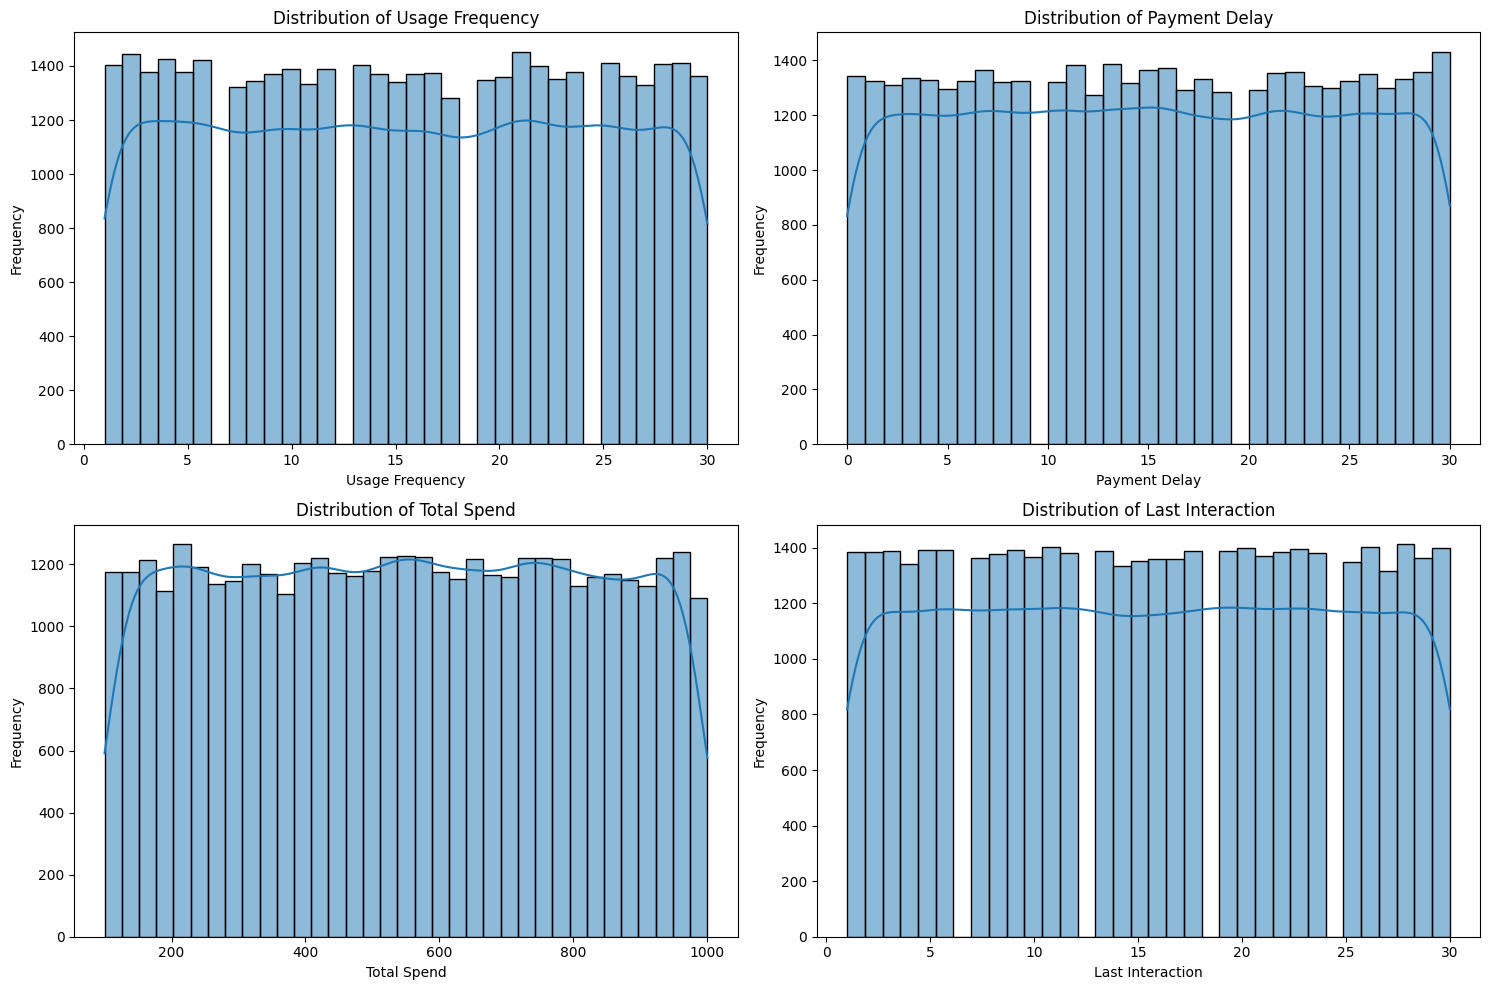

Gender
Female    20726
Male      20589
Name: count, dtype: int64
Gender
Female    50.165799
Male      49.834201
Name: proportion, dtype: float64
Subscription Type
Premium     13868
Standard    13820
Basic       13626
nan             1
Name: count, dtype: int64
Subscription Type
Premium     33.566501
Standard    33.450321
Basic       32.980758
nan          0.002420
Name: proportion, dtype: float64
Contract Length
Monthly      13878
Annual       13730
Quarterly    13706
nan              1
Name: count, dtype: int64
Contract Length
Monthly      33.590706
Annual       33.232482
Quarterly    33.174392
nan           0.002420
Name: proportion, dtype: float64


/tmp/ipykernel_946/2235874397.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/tmp/ipykernel_946/2235874397.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/tmp/ipykernel_946/2235874397.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


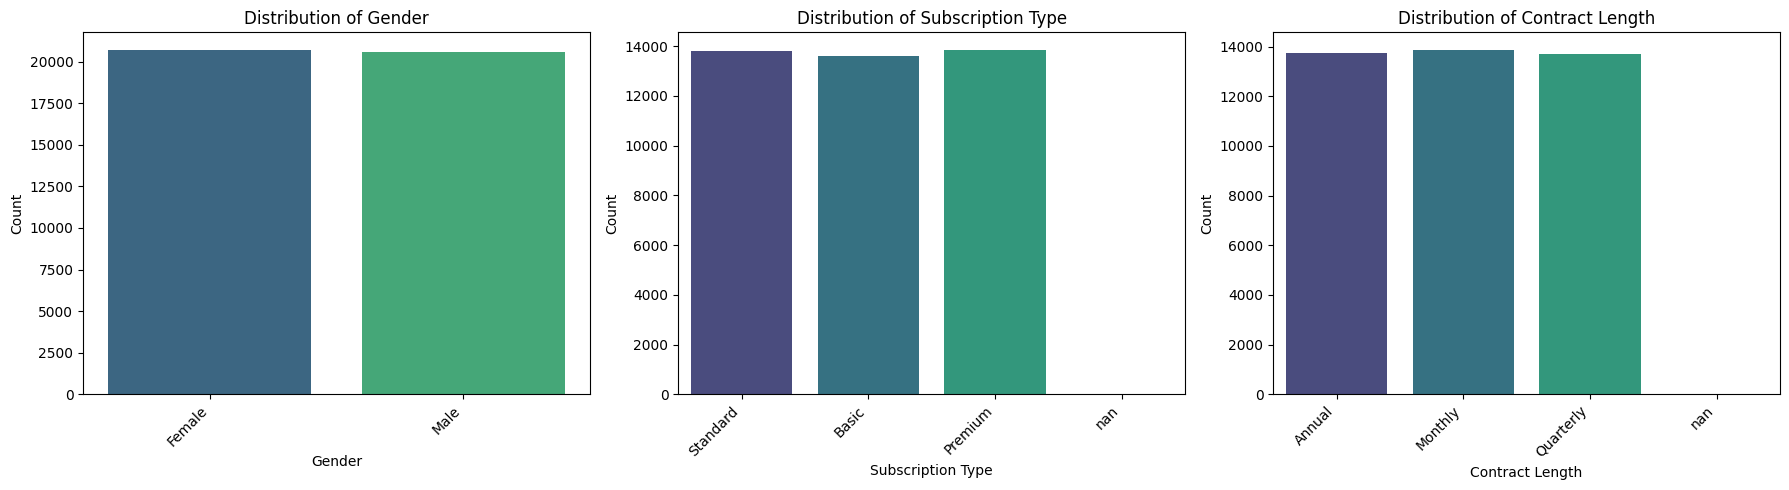

In [13]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


df['Churn'] = df['Churn'].round().astype(int)


display(df['Churn'].value_counts())
display(df['Churn'].value_counts(normalize=True) * 100)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()


numerical_features = ['Usage Frequency', 'Payment Delay', 'Total Spend', 'Last Interaction']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i) # Create a 2x2 grid of subplots
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

for feature in categorical_features:

    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, 3, i) # Create a 1x3 grid of subplots
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()